In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 500

In [2]:
# Datos sintéticos

MedInc = np.random.lognormal(mean=2.5, sigma=0.35, size=n)
HouseAge = np.random.randint(1, 52, size=n)
Longitude = -1254 + np.random.rand(n) * 10 
Latitude = 32 + np.random.rand(n) * 8
AveRooms = 5 + 0.15*MedInc + 0.3*HouseAge + np.random.rand(n)

# target
target = (
    0.45*MedInc
    - 0.2*HouseAge
    -0.3*(Latitude-36)
    -0.1*(Longitude+119)
    + np.random.rand(n)*0.5
)

df = pd.DataFrame(
    {
        "MedInc": MedInc,
        "House_Age": HouseAge,
        "Longitude" : Longitude,
        "Latitude" : Latitude,
        "AveRooms" : AveRooms,
        "Target" : target
    }
)

numeric_cols = df.columns.tolist()

In [3]:
cov_mat = df[numeric_cols].cov()
corr_mat = df[numeric_cols].corr()

print("Covariance Matrix", cov_mat.round(3))
print("Correlation Matrix", corr_mat.round(3))

Covariance Matrix            MedInc  House_Age  Longitude  Latitude  AveRooms  Target
MedInc     22.967     -3.196      0.114     0.694     2.386  10.767
House_Age  -3.196    222.304     -2.162    -0.080    66.078 -45.827
Longitude   0.114     -2.162      8.644     0.390    -0.620  -0.478
Latitude    0.694     -0.080      0.390     5.031     0.090  -1.211
AveRooms    2.386     66.078     -0.620     0.090    20.212 -12.157
Target     10.767    -45.827     -0.478    -1.211   -12.157  14.478
Correlation Matrix            MedInc  House_Age  Longitude  Latitude  AveRooms  Target
MedInc      1.000     -0.045      0.008     0.065     0.111   0.590
House_Age  -0.045      1.000     -0.049    -0.002     0.986  -0.808
Longitude   0.008     -0.049      1.000     0.059    -0.047  -0.043
Latitude    0.065     -0.002      0.059     1.000     0.009  -0.142
AveRooms    0.111      0.986     -0.047     0.009     1.000  -0.711
Target      0.590     -0.808     -0.043    -0.142    -0.711   1.000


In [6]:
# Hat-Matrix

y = df["Target"].values.reshape(-1,1)
X = df[["MedInc", "House_Age", "Longitude", "Latitude", "AveRooms"]].values



In [7]:
XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
beta = XtX_inv @ X.T @ y
y_hat = X @ beta 

resid = y - y_hat

#Hat Matrix
H = X @ XtX_inv @ X.T
leverage = np.diag(H)
print(leverage)

[0.00630043 0.00780624 0.00726231 0.01545779 0.00488905 0.00856724
 0.01438573 0.00768128 0.01373022 0.0114175  0.00751682 0.01097288
 0.00246821 0.0092612  0.01020982 0.00451373 0.00464599 0.00971335
 0.01206332 0.01402262 0.00915066 0.01016173 0.00793992 0.00705952
 0.01229912 0.00269616 0.01406697 0.00790172 0.01091701 0.00336037
 0.01022962 0.02415305 0.00780109 0.01430573 0.01295063 0.01285373
 0.00632906 0.01145656 0.01369766 0.00413973 0.00719538 0.00793365
 0.00870975 0.00924729 0.00794906 0.00929808 0.00775764 0.01352249
 0.01015396 0.018705   0.00426443 0.00325053 0.00825477 0.00610336
 0.01156396 0.0108124  0.00971896 0.00852176 0.00271032 0.01463862
 0.00679265 0.004777   0.01218579 0.00716149 0.00534693 0.01942854
 0.01498679 0.00606888 0.01455145 0.01254705 0.00695925 0.01689636
 0.00394919 0.01183268 0.01742393 0.01417961 0.00396693 0.00789013
 0.01161392 0.00684429 0.00837998 0.00890642 0.01958579 0.0043222
 0.0091762  0.00550637 0.0082146  0.00665889 0.00944208 0.00358

In [10]:
n, p = X.shape
print("n", n)
print("p", p)

avg_lev = p/n
threshold = 2*avg_lev
print("avg_lev", avg_lev)
print("threshold", threshold)

n 500
p 5
avg_lev 0.01
threshold 0.02


In [12]:
summary = pd.DataFrame({
    "index": np.arange(n),
    "leverage": leverage, 
    "y": y.flatten(),
    "y_hat": y_hat.flatten(),
    "resid":resid.flatten()
})

In [14]:
print("Top Ten Leverage Points")
print(summary.sort_values(by="leverage", ascending=False).head(10).round(3))

Top Ten Leverage Points
     index  leverage        y    y_hat  resid
209    209     0.114  134.688  134.553  0.135
478    478     0.051  126.201  126.115  0.085
179    179     0.033  121.676  121.503  0.172
113    113     0.028  118.937  118.840  0.098
234    234     0.027  115.129  115.104  0.025
252    252     0.027  116.294  116.127  0.168
220    220     0.027  121.471  121.378  0.092
284    284     0.025  122.870  122.743  0.127
31      31     0.024  121.800  121.867 -0.067
393    393     0.022  115.107  115.231 -0.124


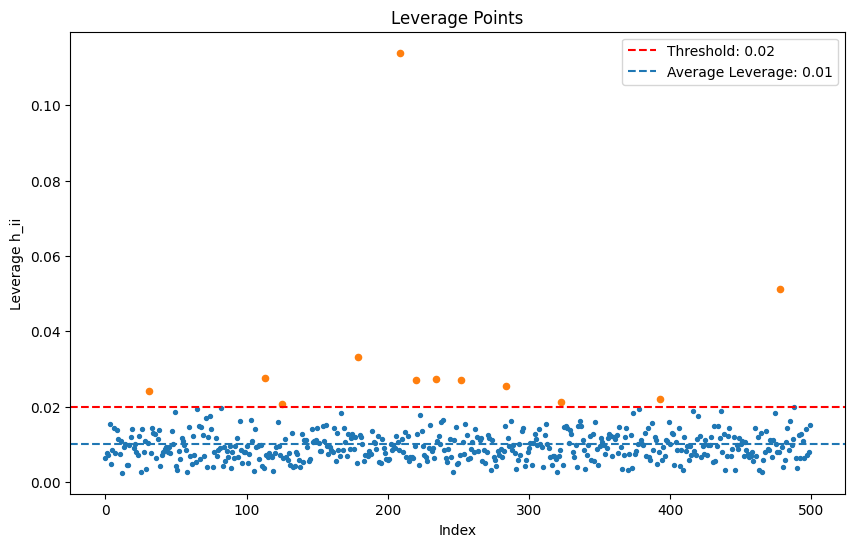

In [16]:
#Plotting leverage 
plt.figure(figsize=(10,6))
plt.scatter(summary["index"], summary["leverage"], s=8)
plt.axhline(threshold, color='r', linestyle='--', label=f'Threshold: {threshold:.2f}')
plt.axhline(avg_lev, linestyle='--', label=f'Average Leverage: {avg_lev:.2f}')
hi_idx = summary.index[summary["leverage"]> threshold].tolist()
if len(hi_idx) > 0: 
    plt.scatter(hi_idx, summary.loc[hi_idx, "leverage"], s=20)
plt.title("Leverage Points")
plt.xlabel("Index")
plt.ylabel("Leverage h_ii")
plt.legend()
plt.show()





In [ ]:
#